# Cross Validation

This notebook summarizes and performs various cross-validation techniques:
- Validation set
- Leave-one-out cross-validation
- K-fold cross validation

Suppose the model is the following:

$$
r_{i}^{t+1} = X_{i}^t \beta + \epsilon_i
$$

where $r_{i}^{t+1}$ is next month return of stock $i$ and X_{i}^t is a matrix of stock characteristics at time $t$, including:
- Investment growth
- Profitability
- Log market equity
- Log book equity
- Accruals

Importantly, we fix the date at 2022-06-30. Thus, we perform a cross-sectional regression

## 0. Required packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import (
    train_test_split, LeaveOneOut, KFold, RepeatedKFold, cross_val_score)

## 1. Load and prepare data

In [3]:
# -----------------------------
# Load + create next-month return
# -----------------------------
data = pd.read_stata("Stocks_Monthly.dta")
data = data.sort_values(["permno", "date"]).copy()

# Make sure date is datetime (robust filtering)
data["date"] = pd.to_datetime(data["date"])

# next month return (t+1)
data["ret_t+1"] = data.groupby("permno")["ret"].shift(-1)

# One pure cross-section (example month)
cs_date = pd.Timestamp("2022-06-30")
cols = ["permno", "date", "Gat", "profit", "LNme", "LNbe", "accruals", "ret_t+1"]
data = data.loc[data["date"].eq(cs_date), cols].dropna().copy()

features = ["Gat", "profit", "LNme", "LNbe", "accruals"]
X = data[features].to_numpy()
y = data["ret_t+1"].to_numpy()

## 2. Helper function for MSE and initialization of the regression model

In [4]:
# -----------------------------
# Helpers
# -----------------------------
def cv_mse(model, X, y, cv):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    fold_mse = -scores
    return fold_mse.mean(), fold_mse.std(ddof=1), fold_mse

lr = LinearRegression()

## 3. Validation set

We split the sample into a training and test sample, with proportions 80% and 20%, respectively.

To assess the variability of test MSE we perform the splitting, regression and prediction 100 times

Average test MSE: 0.04191595838100743
Min-max range of test MSE: 0.030687065369299167 - 0.13381615464846056


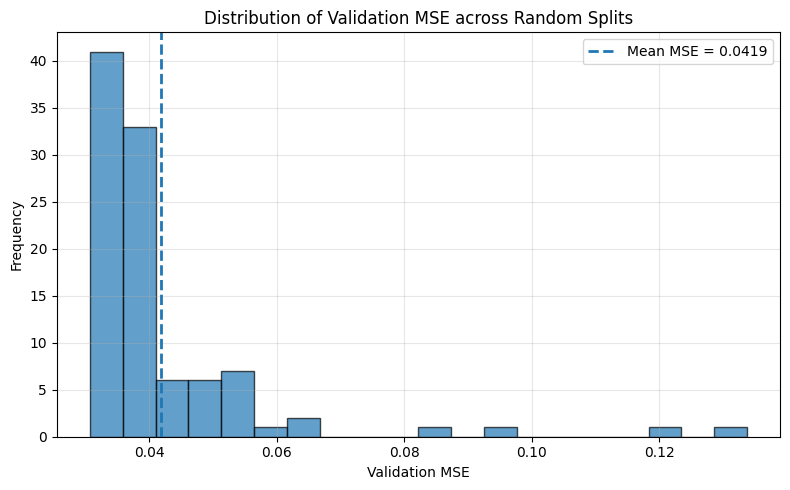

In [5]:
# -----------------------------
# 1) Validation-set approach (ISL)
# -----------------------------
n_reps = 100
val_mse = []
for seed in range(n_reps):
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.8, random_state=seed)
    lr.fit(X_tr, y_tr)
    pred = lr.predict(X_te)
    val_mse.append(np.mean((pred - y_te) ** 2))
val_mse = np.array(val_mse)

# One “single split” number
mse_valset = val_mse.mean()

print(f"Average test MSE: {mse_valset}")
print(f"Min-max range of test MSE: {val_mse.min()} - {val_mse.max()}")


plt.figure(figsize=(8, 5))
plt.hist(val_mse, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mse_valset, linestyle='--', linewidth=2, label=f"Mean MSE = {mse_valset:.4f}")
plt.title("Distribution of Validation MSE across Random Splits")
plt.xlabel("Validation MSE")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Leave-one-out cross-validation

We perform LOOCV. Practically, we perform N regressions and predictions with N-1 observations. The N-th observation is used to predict mext month returns and compute the test MSE

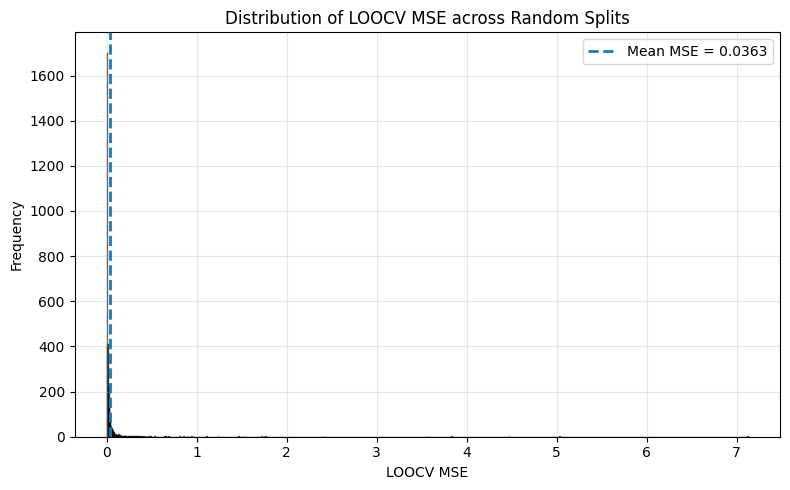

In [13]:
# -----------------------------
# 2) LOOCV (ISL)
# -----------------------------
loo_scores = cross_val_score(lr, X, y, cv=LeaveOneOut(), scoring="neg_mean_squared_error")
mse_loocv = -loo_scores
mean_mse_loocv = mse_loocv.mean()


plt.figure(figsize=(8, 5))

plt.hist(-loo_scores, bins=1000, edgecolor='black', alpha=0.7)
plt.axvline(mean_mse_loocv, linestyle='--', linewidth=2, label=f"Mean MSE = {mean_mse_loocv:.4f}")

plt.title("Distribution of LOOCV MSE across Random Splits")
plt.xlabel("LOOCV MSE")
plt.ylabel("Frequency")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("Ch4_LOOCV_MSE.png", dpi=300, bbox_inches='tight')

## 5. K-fold cross-validation

We perform K-fold cross-validation. After dividing the sample into K folds (groups) we use K-1 folds to train the model and the K-th folds for prediction.

Notice: LOOCV is a special case of K-fold CV when K=N.

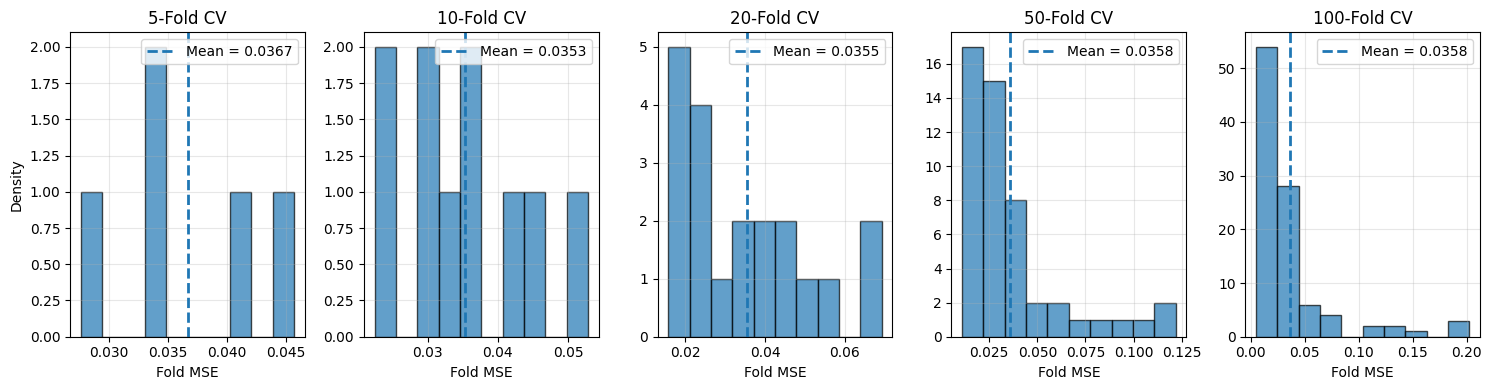

In [14]:
# -----------------------------
# 3) k-fold CV (ISL): show k=5,10,20, 50, 100
# -----------------------------
mse_5fold, sd_5fold, fold_mse_5 = cv_mse(lr, X, y, KFold(n_splits=5, shuffle=True, random_state=0))
mse_10fold, sd_10fold, fold_mse_10 = cv_mse(lr, X, y, KFold(n_splits=10, shuffle=True, random_state=0))
mse_20fold, sd_20fold, fold_mse_20 = cv_mse(lr, X, y, KFold(n_splits=20, shuffle=True, random_state=0))
mse_50fold, sd_50fold, fold_mse_50 = cv_mse(lr, X, y, KFold(n_splits=50, shuffle=True, random_state=0))
mse_100fold, sd_100fold, fold_mse_100 = cv_mse(lr, X, y, KFold(n_splits=100, shuffle=True, random_state=0))

# -----------------------------
# Histograms for K-Fold CV MSEs
# -----------------------------
fig, axes = plt.subplots(1, 5, figsize=(15, 4), sharey=False)

configs = [
    (fold_mse_5, mse_5fold, "5-Fold CV"),
    (fold_mse_10, mse_10fold, "10-Fold CV"),
    (fold_mse_20, mse_20fold, "20-Fold CV"),
    (fold_mse_50, mse_50fold, "50-Fold CV"),
    (fold_mse_100, mse_50fold, "100-Fold CV")
]

for ax, (fold_mse, mean_mse, title) in zip(axes, configs):
    ax.hist(fold_mse, bins=10, edgecolor='black', alpha=0.7, density=False)
    ax.axvline(mean_mse, linestyle='--', linewidth=2, label=f"Mean = {mean_mse:.4f}")

    ax.set_title(title)
    ax.set_xlabel("Fold MSE")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_ylabel("Density")

plt.tight_layout()
plt.savefig("Ch4_KFOLD_MSE.png", dpi=300, bbox_inches='tight')